# VedaVision — Compound Leaf Preprocessing (Fixed · Single-Image Experiment)
**Module:** Compound Leaf Analysis  
**Purpose:** Experiment and verify pipeline on ONE image before batch processing  
**Fixes applied vs previous version:**

| Fix | What was removed | Why |
|---|---|---|
| **Fix 1** | `area_px`, `perimeter_px`, `eq_diameter_px`, `bbox_w/h`, `vein_pixel_count`, `vein_branch_points`, raw whole-leaf area/bbox/spacing px values | Scale-dependent — change with zoom/distance |
| **Fix 2** | `ellipse_angle` | Pose-dependent — measures table placement, not species trait |
| **Fix 3** | `n_leaflets`, `leaf_type_inferred`, `whole_bbox_w/h`, `whole_area_total/mean/min/max`, `whole_spacing_mean`, `whole_rachis_len_est` | `n_leaflets` varies branch-to-branch; string features break classifiers; rest are scale-dependent |
| **Segmentation** | Entire watershed/component segmentation block | Was producing wrong splits — features now on whole-leaf mask |

---
### How to use this notebook
1. **Set `IMAGE_PATH`, `SPECIES`, `VIEW_SIDE`** in Cell 1 — that is the only cell you need to change  
2. Run all cells top to bottom  
3. Inspect the visual output at each step  
4. When happy, use Cell 13 (Batch) to process your full dataset

---
### Pipeline
```
IMAGE_PATH (your file)
   ↓
Cell 2 : Load + display original
   ↓
Cell 3 : Letterbox resize → 512×512 (aspect-ratio preserving)
   ↓
Cell 4 : LAB + ExG dual-mask background removal
   ↓
Cell 5 : Enhancement — Bilateral → CLAHE → Unsharp mask
   ↓
Cell 6 : Shape features  (11 dims — dimensionless ratios + Hu moments)
   ↓
Cell 7 : Colour features (44 dims — channel stats + hue histogram)
   ↓
Cell 8 : Texture features (36 dims — GLCM + LBP)
   ↓
Cell 9 : Vein features   (4 dims  — normalised skeleton ratios)
   ↓
Cell 10: Whole-leaf structural features (5 dims — stable ratios only)
   ↓
Cell 11: Assemble → flat feature vector → display + save CSV
   ↓
Cell 12: Visual summary (all pipeline stages in one figure)
   ↓
Cell 13: Batch processing (entire dataset folder)
```

## Cell 1 — ⚙️ Configuration  ← CHANGE THIS CELL ONLY

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CHANGE THESE THREE VALUES — everything else runs automatically
# ═══════════════════════════════════════════════════════════════════════════════

# IMAGE_PATH = '../dataset/raw/nil_awariya.jpg'   # ← path to your image file
# IMAGE_PATH = '../dataset/raw/thunpath_kurundu.jpg'   # ← path to your image file
IMAGE_PATH = '../dataset/raw/kattakumanjal.jpg'   # ← path to your image file
                                    

# SPECIES    = 'nil_awariya'               # ← species name (used in CSV metadata)
# SPECIES    = 'thunpath_kurundu'              
SPECIES    = 'kattakumanjal'              

VIEW_SIDE  = 'top'                 

# ══════════════════════════════════════════════════════════════════════════════
# Pipeline parameters — reasoned defaults, no magic numbers
# ═══════════════════════════════════════════════════════════════════════════════
TARGET_LONG   = 512       # Longest side target px. 512 = power-of-two, preserves
                          # vein detail on small Moringa leaflets (224 would under-resolve)

MIN_COMP_FRAC = 0.001     # Min connected component size as fraction of image area
                          # 0.1% of 512² = 262 px² — removes dust/speckle noise

LBP_RADIUS    = 3         # LBP neighbourhood radius in px
LBP_POINTS    = 24        # LBP sample points = 8 × radius (standard relationship)

GLCM_DIST     = [1, 3]   # GLCM distances: 1=immediate neighbours, 3=medium range
                          # Two distances capture both fine and coarse texture structure
GLCM_ANGLES   = [0, 1.5707963, 0.7853981, 2.3561944]  # 0°, 90°, 45°, 135°
                          # Four angles → averaged for rotation invariance

print('Configuration loaded.')
print(f'  Image   : {IMAGE_PATH}')
print(f'  Species : {SPECIES}')
print(f'  View    : {VIEW_SIDE}')


Configuration loaded.
  Image   : ../dataset/raw/nil_awariya.jpg
  Species : nil_awariya
  View    : top


## Cell 2 — Imports

In [22]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.morphology import skeletonize

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 9

def show(pairs, cols=4, suptitle=None):
    """Display list of (image, title) tuples in a grid."""
    n    = len(pairs)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten()
    for ax, (img, title) in zip(axes, pairs):
        if img.ndim == 2:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    for ax in axes[n:]:
        ax.axis('off')
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Imports OK')


Imports OK


## Cell 3 — Load Image

Loaded : ../dataset/raw/nil_awariya.jpg
Shape  : (4032, 3024, 3)  (H × W × C)
dtype  : uint8
AR     : 0.750  (w/h)


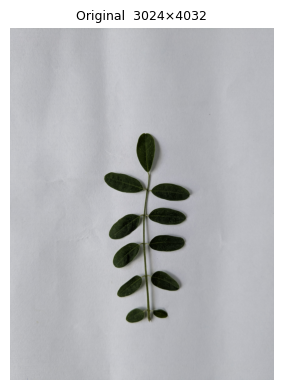

In [23]:
import os

assert os.path.exists(IMAGE_PATH), (
    f'Image not found: {IMAGE_PATH}\n'
    f'Check IMAGE_PATH in Cell 1.'
)

img_orig = cv2.imread(IMAGE_PATH)
assert img_orig is not None, f'cv2.imread failed on: {IMAGE_PATH}'

print(f'Loaded : {IMAGE_PATH}')
print(f'Shape  : {img_orig.shape}  (H × W × C)')
print(f'dtype  : {img_orig.dtype}')
print(f'AR     : {img_orig.shape[1] / img_orig.shape[0]:.3f}  (w/h)')

show([(img_orig, f'Original  {img_orig.shape[1]}×{img_orig.shape[0]}')], cols=1)


## Cell 4 — Letterbox Resize (Aspect-Ratio Preserving)

**Why letterbox and NOT naive `resize(512,512)`?**  
A tall Moringa leaf (AR≈0.25) naively resized becomes squashed — your `aspect_ratio` 
feature would then measure the distortion you introduced, not the leaf's true shape.  
Letterbox = scale longest side to 512px, pad the short side with white.

**Why white padding?**  
Matches dataset background → background removal sees uniform white border → correct mask seeding.

Original  : 3024w × 4032h  AR=0.750
Scaled to : 384w × 512h  (scale=0.1270)
Padded to : 512w × 512h
AR before : 0.7500
AR after  : 0.7500  ← must match above
Pad top=0px  left=64px


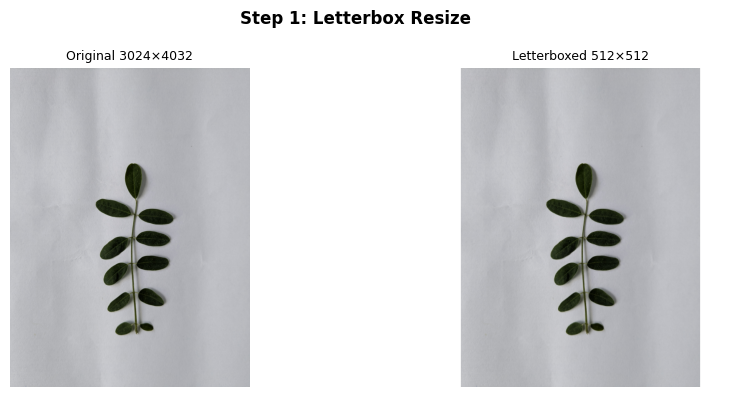

In [24]:
def letterbox_resize(img, target_long=512, pad_colour=(255, 255, 255)):
    """
    Scale longest side to target_long, pad short side to make square.
    Returns (padded_img, meta_dict).
    pad_colour = white: matches dataset background so mask seeding is unaffected.
    INTER_AREA for downscale: averages source pixels → no aliasing on vein patterns.
    INTER_LINEAR for upscale: smooth, no ringing.
    """
    h, w   = img.shape[:2]
    scale  = target_long / max(h, w)
    new_w  = int(round(w * scale))
    new_h  = int(round(h * scale))
    interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    scaled = cv2.resize(img, (new_w, new_h), interpolation=interp)

    pad_h      = target_long - new_h
    pad_w      = target_long - new_w
    pad_top    = pad_h // 2;  pad_bottom = pad_h - pad_top
    pad_left   = pad_w // 2;  pad_right  = pad_w - pad_left

    padded = cv2.copyMakeBorder(scaled, pad_top, pad_bottom, pad_left, pad_right,
                                 cv2.BORDER_CONSTANT, value=pad_colour)
    meta = dict(scale=scale, pad_top=pad_top, pad_left=pad_left,
                orig_h=h, orig_w=w, new_h=new_h, new_w=new_w)
    return padded, meta


img_resized, resize_meta = letterbox_resize(img_orig, TARGET_LONG)

print(f'Original  : {img_orig.shape[1]}w × {img_orig.shape[0]}h  AR={img_orig.shape[1]/img_orig.shape[0]:.3f}')
print(f'Scaled to : {resize_meta["new_w"]}w × {resize_meta["new_h"]}h  (scale={resize_meta["scale"]:.4f})')
print(f'Padded to : {img_resized.shape[1]}w × {img_resized.shape[0]}h')
print(f'AR before : {resize_meta["orig_w"]/resize_meta["orig_h"]:.4f}')
print(f'AR after  : {resize_meta["new_w"]/resize_meta["new_h"]:.4f}  ← must match above')
print(f'Pad top={resize_meta["pad_top"]}px  left={resize_meta["pad_left"]}px')

show([
    (img_orig,    f'Original {img_orig.shape[1]}×{img_orig.shape[0]}'),
    (img_resized, f'Letterboxed {TARGET_LONG}×{TARGET_LONG}'),
], cols=2, suptitle='Step 1: Letterbox Resize')


## Cell 5 — Background Removal (LAB + ExG Dual-Mask)

**Why LAB 'a' channel?**  
The 'a' axis encodes green↔red. Green leaves are strongly negative on 'a'. 
Inverted, leaf pixels become bright → adaptive threshold cleanly separates them from white paper.

**Why ExG (Excess Green = 2G−R−B)?**  
A second, independent greenness test. White paper: ExG≈0. Green leaf: ExG>5–30.  
AND-ing LAB and ExG masks removes paper shadows that fool LAB alone.

**Why dual threshold (30 and 5)?**  
- Tight (ExG>30): preserves inter-leaflet white gaps — good for visualisation  
- Loose (ExG>5): captures dark/shaded leaves — more complete leaf coverage  
The notebook picks tight if it produces ≥3 components AND covers ≥30% of loose area.

Tight  mask  (ExG>30, no-close) : 3 components
Medium mask  (ExG>3,  no-close) : 1 components
Loose  mask  (ExG>3,  + close)  : 1 components
Selected     : loose (ExG>3, with-close)


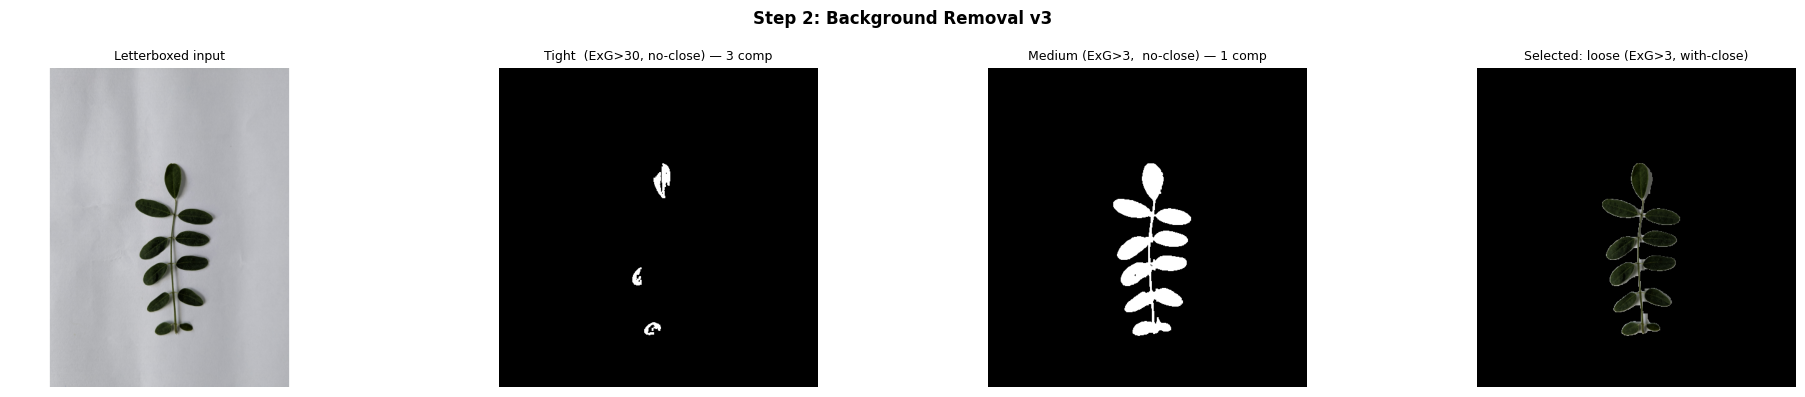

In [27]:
# ═══════════════════════════════════════════════════════
# CELL 10 — FIXED Background Removal  (Pipeline v3)
# ═══════════════════════════════════════════════════════

def _build_mask(img_bgr, exg_threshold, apply_morph_close=False):
    """
    Binary leaf mask via LAB adaptive threshold AND ExG vegetation index.
    
    KEY CHANGE vs v2:
    - morph_close is now OPTIONAL and OFF by default.
      Closing was bridging inter-leaflet gaps which are taxonomically
      meaningful for compound leaf structure features.
    - ExG threshold lowered (caller decides: 30 tight, 3 loose).
    """
    lab       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    _, a, _   = cv2.split(lab)
    green_map = cv2.bitwise_not(a)

    block_size = max(11, (TARGET_LONG // 9) | 1)
    mask_lab   = cv2.adaptiveThreshold(
        green_map, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        block_size, 10
    )

    img_f    = img_bgr.astype(np.float32)
    exg      = 2 * img_f[:,:,1] - img_f[:,:,2] - img_f[:,:,0]
    mask_exg = (exg > exg_threshold).astype(np.uint8) * 255

    combined = cv2.bitwise_and(mask_lab, mask_exg)
    k3       = np.ones((3, 3), np.uint8)
    
    # OPEN always (removes dust/noise speckles)
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN, k3, iterations=1)
    
    # CLOSE only when caller says so (default OFF — preserve leaflet gaps)
    if apply_morph_close:
        combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k3, iterations=2)
    
    return combined


def _remove_noise(mask, min_frac=None):
    """Remove connected components smaller than min_frac of image area."""
    if min_frac is None:
        min_frac = MIN_COMP_FRAC
    min_area = TARGET_LONG * TARGET_LONG * min_frac
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] > min_area:
            clean[lbl == i] = 255
    return clean


def _component_stats(mask):
    """Return (n_components, total_foreground_px, largest_component_px)."""
    n, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    n -= 1  # subtract background
    if n == 0:
        return 0, 0, 0
    areas = [stats[i, cv2.CC_STAT_AREA] for i in range(1, n + 1)]
    return n, int(np.sum(areas)), int(np.max(areas))


def select_mask(img_resized):
    """
    v3 Adaptive mask selection logic.
    
    Three masks instead of two:
      - tight  ExG>30  no-close  → preserves gaps, handles bright/well-lit
      - medium ExG>3   no-close  → captures dark tissue without closing gaps  ← NEW
      - loose  ExG>3   with-close → fallback: full silhouette for trifoliate
    
    Selection priority:
      1. If tight has >= 3 components AND largest component covers >= 40% of
         loose area → tight leaflets are real, not fragments → USE TIGHT
      2. Else if medium has >= 2 components AND coverage > 5% of image → USE MEDIUM
      3. Else → USE LOOSE (trifoliate, heavily overlapping, or dark specimens)
    """
    img_area = TARGET_LONG * TARGET_LONG

    mask_tight  = _remove_noise(_build_mask(img_resized, exg_threshold=30, apply_morph_close=False))
    mask_medium = _remove_noise(_build_mask(img_resized, exg_threshold=3,  apply_morph_close=False))
    mask_loose  = _remove_noise(_build_mask(img_resized, exg_threshold=3,  apply_morph_close=True))

    n_tight,  px_tight,  largest_tight  = _component_stats(mask_tight)
    n_medium, px_medium, largest_medium = _component_stats(mask_medium)
    n_loose,  px_loose,  _              = _component_stats(mask_loose)

    # Guard: if loose has almost nothing, fall back to medium regardless
    if px_loose < img_area * 0.02:
        return mask_medium, 'medium (ExG>3, fallback: low coverage)', \
               n_tight, n_medium, n_loose

    # Rule 1: tight mask separates real leaflets (not just fragments)
    # Key insight: if largest fragment in tight >= 40% of loose total,
    # the leaflets are large and real, not fragmented internal noise
    if n_tight >= 3 and px_loose > 0:
        frac = largest_tight / px_loose
        if frac >= 0.40:
            return mask_tight, 'tight (ExG>30, good leaflet separation)', \
                   n_tight, n_medium, n_loose

    # Rule 2: medium captures dark/shadowed tissue without closing gaps
    if n_medium >= 2 and px_medium > img_area * 0.05:
        return mask_medium, 'medium (ExG>3, no-close)', \
               n_tight, n_medium, n_loose

    # Rule 3: loose fallback — trifoliate or dense overlapping leaves
    return mask_loose, 'loose (ExG>3, with-close)', \
           n_tight, n_medium, n_loose


# ── Run ───────────────────────────────────────────────────────────────────────
mask_final, mask_choice, n_t, n_m, n_l = select_mask(img_resized)

# Rebuild individual masks for display
mask_tight_vis  = _remove_noise(_build_mask(img_resized, 30,  False))
mask_medium_vis = _remove_noise(_build_mask(img_resized, 3,   False))

img_masked    = cv2.bitwise_and(img_resized, img_resized, mask=mask_final)
img_segmented = img_masked

print(f'Tight  mask  (ExG>30, no-close) : {n_t} components')
print(f'Medium mask  (ExG>3,  no-close) : {n_m} components')
print(f'Loose  mask  (ExG>3,  + close)  : {n_l} components')
print(f'Selected     : {mask_choice}')

show([
    (img_resized,    'Letterboxed input'),
    (mask_tight_vis, f'Tight  (ExG>30, no-close) — {n_t} comp'),
    (mask_medium_vis,f'Medium (ExG>3,  no-close) — {n_m} comp'),
    (img_masked,     f'Selected: {mask_choice}'),
], cols=4, suptitle='Step 2: Background Removal v3')

## Cell 6 — Enhancement (Bilateral → CLAHE → Unsharp Mask)
Applied only inside the leaf mask. Used for texture and vein extraction — NOT for segmentation.

- **Bilateral filter** (d=9, σ=75): smooths within-leaflet noise, preserves vein edges  
- **CLAHE** (clip=2.5, tile=8×8 on L channel): locally boosts contrast for vein visibility without distorting colour  
- **Unsharp mask** (σ=3, strength=1.5×): sharpens vein boundaries for skeleton extraction

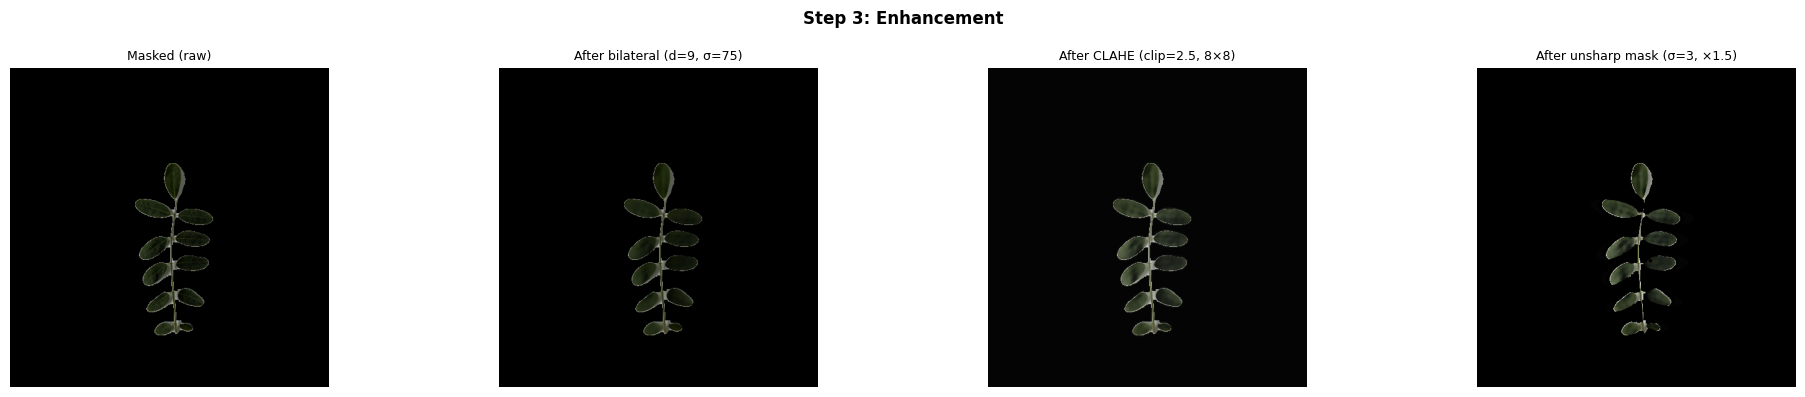

In [36]:
# ── Bilateral filter ─────────────────────────────────────────────────────────
# d=9: 9px neighbourhood diameter — OpenCV recommended for real-time use
# sigmaColor=75: ~30% of 255 range; bridges camera noise (~10 units) but
#   keeps vein-lamina boundary (~40 units) intact
# sigmaSpace=75: spatial influence radius matches sigmaColor for balance
img_bilateral = cv2.bilateralFilter(img_masked, d=9, sigmaColor=75, sigmaSpace=75)

# ── CLAHE on L channel only ───────────────────────────────────────────────────
# Operating in LAB: L=lightness, a/b=colour. Enhancing L boosts contrast
# without shifting the green hue — critical if colour features follow.
# clipLimit=2.5: mid-range clip; 1.0=no enhancement, 4.0=amplifies noise
# tileGridSize=(8,8): 512/8=64px tiles — spatially adaptive, not global
lab_e       = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2LAB)
l, a_e, b_e = cv2.split(lab_e)
clahe       = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
l_clahe     = clahe.apply(l)
img_clahe   = cv2.cvtColor(cv2.merge([l_clahe, a_e, b_e]), cv2.COLOR_LAB2BGR)

# ── Unsharp mask ──────────────────────────────────────────────────────────────
# GaussianBlur σ=3 captures structures up to ~9px wide (3σ rule)
# addWeighted: sharp = 1.5×original − 0.5×blurred = original + 0.5×(orig−blur)
# Strength 1.5 chosen to reveal secondary veins without amplifying JPEG artefacts
blur      = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=3)
img_sharp = cv2.addWeighted(img_clahe, 1.5, blur, -0.5, 0)
img_sharp = cv2.bitwise_and(img_sharp, img_sharp, mask=mask_final)  # re-apply mask

show([
    (img_masked,    'Masked (raw)'),
    (img_bilateral, 'After bilateral (d=9, σ=75)'),
    (img_clahe,     'After CLAHE (clip=2.5, 8×8)'),
    (img_sharp,     'After unsharp mask (σ=3, ×1.5)'),
], cols=4, suptitle='Step 3: Enhancement')


## Cell 7 — Shape Features (Whole-Leaf Mask)
**Fix 1 applied:** `area_px`, `perimeter_px`, `eq_diameter_px`, `bbox_w`, `bbox_h` removed — all scale-dependent raw pixel counts.  
**Fix 2 applied:** `ellipse_angle` removed — measures how leaf was placed on table, not species morphology.  
All remaining features are **dimensionless ratios** or **log-transformed moments** — invariant to image scale.

In [ ]:
def extract_shape_features(leaf_mask):
    """
    Shape descriptors from whole-leaf binary mask.
    All dimensionless — a leaf at any zoom gives the same values.

    REMOVED (Fix 1 — scale-dependent):
        area_px, perimeter_px, eq_diameter_px, bbox_w, bbox_h
    REMOVED (Fix 2 — pose-dependent):
        ellipse_angle  (the angle a leaf is placed on the table ≠ species trait)

    KEPT:
        aspect_ratio   w/h of bounding box        — elongation
        circularity    4π·A/P²                    — circle=1, needle→0
        convexity      A/hull_A                   — margin smoothness
        solidity       alias of convexity          — standard botany term
        compactness    A/bbox_A                   — rectangular fill
        elongation     minor/major ellipse axis   — pose-invariant elongation
        hu_1..hu_7     log-Hu moments             — rotation+scale+translation invariant
    """
    cnts, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not cnts:
        return {}
    cnt = max(cnts, key=cv2.contourArea)

    area      = float(cv2.contourArea(cnt))
    perimeter = float(cv2.arcLength(cnt, closed=True))
    x, y, w, h = cv2.boundingRect(cnt)

    aspect_ratio = float(w) / h if h > 0 else 0.0
    compactness  = area / (w * h) if (w * h) > 0 else 0.0
    circularity  = (4 * np.pi * area / perimeter ** 2) if perimeter > 0 else 0.0
    hull         = cv2.convexHull(cnt)
    hull_area    = float(cv2.contourArea(hull))
    convexity    = area / hull_area if hull_area > 0 else 0.0
    solidity     = convexity

    # Elongation from fitted ellipse — minor/major axis ratio only (angle discarded, Fix 2)
    if len(cnt) >= 5:
        (_, _), (ma, mi), _ = cv2.fitEllipse(cnt)
        elongation = mi / ma if ma > 0 else 0.0
    else:
        elongation = 0.0

    # Hu moments: 7 values, rotation+scale+translation invariant
    M      = cv2.moments(cnt)
    hu     = cv2.HuMoments(M).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    feats = {
        'aspect_ratio': aspect_ratio,
        'circularity' : circularity,
        'convexity'   : convexity,
        'solidity'    : solidity,
        'compactness' : compactness,
        'elongation'  : elongation,
        # area_px, perimeter_px, eq_diameter_px, bbox_w, bbox_h → REMOVED Fix 1
        # ellipse_angle → REMOVED Fix 2
    }
    for i, val in enumerate(hu_log):
        feats[f'hu_{i+1}'] = float(val)
    return feats


shape_feats = extract_shape_features(mask_final)

print(f'Shape features: {len(shape_feats)} dims')
print()
for k, v in shape_feats.items():
    print(f'  {k:<18s}: {v:>10.6f}')

# Visualise contour + ellipse fit
shape_vis = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).copy()
cnts_v, _ = cv2.findContours(mask_final, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(shape_vis, cnts_v, -1, (0, 200, 100), 2)
if cnts_v:
    cnt_v = max(cnts_v, key=cv2.contourArea)
    if len(cnt_v) >= 5:
        cv2.ellipse(shape_vis, cv2.fitEllipse(cnt_v), (255, 120, 0), 1)

show([
    (img_masked,  'Masked leaf'),
    (shape_vis,   f'Contour (green) + ellipse (orange)\n'
                   f'AR={shape_feats["aspect_ratio"]:.3f}  '
                   f'Circ={shape_feats["circularity"]:.3f}  '
                   f'Conv={shape_feats["convexity"]:.3f}  '
                   f'Elong={shape_feats["elongation"]:.3f}'),
], cols=2, suptitle='Step 4a: Shape Features')


## Cell 8 — Colour Features (Whole-Leaf Mask)
Channel statistics (mean + std) in BGR, HSV, LAB + Excess Green + normalised hue histogram. All are inherently scale-independent — they are pixel intensity statistics, not pixel counts.

In [ ]:
def extract_colour_features(img_bgr, leaf_mask):
    """
    Colour statistics from masked leaf pixels.
    BGR, HSV, LAB channel mean+std + ExG + normalised hue histogram (18 bins).
    All scale-independent: these are per-pixel intensity statistics.
    """
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    img_f   = img_bgr.astype(np.float32)
    exg     = 2 * img_f[:,:,1] - img_f[:,:,2] - img_f[:,:,0]
    px      = leaf_mask > 0
    feats   = {}

    def _stats(arr, prefix):
        vals = arr[px]
        feats[f'{prefix}_mean'] = float(np.mean(vals)) if len(vals) else 0.0
        feats[f'{prefix}_std']  = float(np.std(vals))  if len(vals) else 0.0

    for i, n in enumerate(['b', 'g', 'r']):
        _stats(img_bgr[:,:,i], f'bgr_{n}')
    for i, n in enumerate(['h', 's', 'v']):
        _stats(img_hsv[:,:,i], f'hsv_{n}')
    for i, n in enumerate(['l', 'a', 'b']):
        _stats(img_lab[:,:,i], f'lab_{n}')
    _stats(exg, 'exg')

    # Hue histogram — 18 bins × 20°/bin = 0°–180° (OpenCV scale)
    # Normalised: counts/total → sums to 1.0 → scale invariant
    h_vals = img_hsv[:,:,0][px].astype(np.float32)
    if len(h_vals) > 0:
        hist, _ = np.histogram(h_vals, bins=18, range=(0, 180))
        hist    = hist / (hist.sum() + 1e-6)
        for bi, bv in enumerate(hist):
            feats[f'hue_hist_{bi:02d}'] = float(bv)

    return feats


colour_feats = extract_colour_features(img_resized, mask_final)

print(f'Colour features: {len(colour_feats)} dims')
print()
print(f'  {"Feature":<20s}  {"Value":>8s}')
print(f'  {"-"*30}')
for k in ['bgr_g_mean','hsv_h_mean','hsv_s_mean','hsv_v_mean',
          'lab_l_mean','lab_a_mean','lab_b_mean','exg_mean']:
    print(f'  {k:<20s}: {colour_feats[k]:>8.3f}')

# Visualise colour channels
img_hsv_v = cv2.cvtColor(img_masked, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(img_hsv_v)
h_col = cv2.applyColorMap(cv2.bitwise_and(h_ch, h_ch, mask=mask_final), cv2.COLORMAP_HSV)

show([
    (img_masked, 'Masked leaf (BGR)'),
    (h_col,      'Hue (false colour)'),
    (cv2.bitwise_and(s_ch, s_ch, mask=mask_final), 'Saturation'),
    (cv2.bitwise_and(v_ch, v_ch, mask=mask_final), 'Value'),
], cols=4, suptitle='Step 4b: Colour Features')


## Cell 9 — Texture Features (GLCM + LBP, Whole Leaf)
Both features are inherently scale-independent: GLCM uses `normed=True` (co-occurrence ratios), LBP histogram is normalised by pixel count.

In [ ]:
def extract_texture_features(img_sharp_bgr, leaf_mask):
    """
    GLCM + LBP texture features on sharpened whole-leaf image.
    Both normalised → scale-independent.

    GLCM: computed at 2 distances × 4 angles → mean+std per property (rotation invariant)
    LBP : P=24, R=3 → 26 uniform pattern bins, normalised histogram
    """
    gray    = cv2.cvtColor(img_sharp_bgr, cv2.COLOR_BGR2GRAY)
    px_mask = leaf_mask > 0
    if px_mask.sum() < 50:
        return {}
    feats = {}

    # ── GLCM ─────────────────────────────────────────────────────────────────
    ys, xs  = np.where(px_mask)
    y1,y2   = ys.min(), ys.max()+1
    x1,x2   = xs.min(), xs.max()+1
    gray_q  = (gray[y1:y2, x1:x2] // 4).astype(np.uint8)  # 256→64 levels
    # 64 levels: each bin spans 4 intensity units — enough to distinguish
    # vein (dark) from lamina (bright) while keeping matrix computationally tractable

    glcm = graycomatrix(gray_q, distances=GLCM_DIST, angles=GLCM_ANGLES,
                        levels=64, symmetric=True, normed=True)
    for prop in ['contrast', 'homogeneity', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop)          # shape: (n_dist, n_angles)
        feats[f'glcm_{prop}_mean'] = float(vals.mean())
        feats[f'glcm_{prop}_std']  = float(vals.std())

    # ── LBP ──────────────────────────────────────────────────────────────────
    lbp      = local_binary_pattern(gray, LBP_POINTS, LBP_RADIUS, method='uniform')
    n_bins   = LBP_POINTS + 2
    lbp_vals = lbp[px_mask]
    lbp_hist, _ = np.histogram(lbp_vals, bins=n_bins, range=(0, n_bins))
    lbp_hist = lbp_hist / (lbp_hist.sum() + 1e-6)   # normalise
    for bi, bv in enumerate(lbp_hist):
        feats[f'lbp_{bi:02d}'] = float(bv)
    feats['lbp_mean'] = float(lbp_vals.mean()) if len(lbp_vals) else 0.0
    feats['lbp_std']  = float(lbp_vals.std())  if len(lbp_vals) else 0.0

    return feats


texture_feats = extract_texture_features(img_sharp, mask_final)

print(f'Texture features: {len(texture_feats)} dims')
print()
for k in ['glcm_contrast_mean','glcm_homogeneity_mean',
          'glcm_energy_mean','glcm_correlation_mean']:
    print(f'  {k:<30s}: {texture_feats[k]:.6f}')
print(f'  ... + {LBP_POINTS+2} LBP histogram bins')

gray_s  = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2GRAY)
lbp_vis = local_binary_pattern(gray_s, LBP_POINTS, LBP_RADIUS, method='uniform')
lbp_vis = (lbp_vis / (LBP_POINTS + 2) * 255).astype(np.uint8)
lbp_vis = cv2.bitwise_and(lbp_vis, lbp_vis, mask=mask_final)

show([
    (img_sharp,  'Sharpened leaf'),
    (gray_s,     'Grayscale'),
    (lbp_vis,    f'LBP (R={LBP_RADIUS}, P={LBP_POINTS})'),
], cols=3, suptitle='Step 4c: Texture Features')


## Cell 10 — Vein Features (Whole Leaf)
**Fix 1 applied:**  
- `vein_pixel_count` removed — raw skeleton px count, changes with image zoom  
- `vein_branch_points` removed — raw count, scales with area  
- `vein_end_points` removed — raw count, scales with area  

Replaced with **density versions** (divided by leaf area) → all 4 remaining features are dimensionless ratios.

In [ ]:
def extract_vein_features(img_sharp_bgr, leaf_mask):
    """
    Vein skeleton features — all normalised by area or perimeter.

    REMOVED (Fix 1 — scale-dependent raw counts):
        vein_pixel_count    → use vein_density instead
        vein_branch_points  → use vein_branch_density instead
        vein_end_points     → use vein_end_point_density instead

    KEPT (all dimensionless):
        vein_density          skeleton_px / leaf_area_px
        vein_length_ratio     skeleton_px / contour_perimeter
        vein_branch_density   branch_points / leaf_area_px
        vein_end_point_density end_points  / leaf_area_px

    Extraction: Black Top-Hat → adaptive threshold → skeletonize
    """
    gray    = cv2.cvtColor(img_sharp_bgr, cv2.COLOR_BGR2GRAY)
    px_mask = leaf_mask > 0
    if px_mask.sum() < 100:
        return {}, None, None
    feats = {}

    # ── Black Top-Hat: highlights dark veins on bright lamina ────────────────
    # Kernel size = expected vein width at 512px resolution.
    # Secondary veins ≈ 10–15px wide → kernel=15 captures them without merging
    k_bthat      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    black_tophat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, k_bthat)
    black_tophat = cv2.bitwise_and(black_tophat, black_tophat, mask=leaf_mask)

    # ── Adaptive threshold on top-hat result ─────────────────────────────────
    # Block size ~image_height/20 (odd) — adapts to image scale automatically
    # C=−2: include only pixels ABOVE local mean (suppress flat lamina)
    blk         = max(11, (gray.shape[0] // 20) | 1)
    vein_binary = cv2.adaptiveThreshold(
        black_tophat, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,
        blk, -2
    )
    vein_binary = cv2.bitwise_and(vein_binary, vein_binary, mask=leaf_mask)

    # ── Skeletonize → 1-px-wide vein centrelines ─────────────────────────────
    vein_skel    = skeletonize(vein_binary > 0).astype(np.uint8) * 255
    leaf_area_px = float(px_mask.sum())
    skel_px      = float((vein_skel > 0).sum())

    # ── vein_density (scale invariant) ───────────────────────────────────────
    feats['vein_density'] = skel_px / leaf_area_px if leaf_area_px > 0 else 0.0

    # ── vein_length_ratio (normalised by perimeter) ───────────────────────────
    cnts, _   = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    perimeter = float(cv2.arcLength(max(cnts, key=cv2.contourArea), True)) if cnts else 1.0
    feats['vein_length_ratio'] = skel_px / perimeter if perimeter > 0 else 0.0

    # ── Branch + end point DENSITIES (Fix 1: density not raw count) ──────────
    k_n              = np.ones((3,3), np.uint8);  k_n[1,1] = 0
    skel_b           = (vein_skel > 0).astype(np.uint8)
    nbr              = cv2.filter2D(skel_b.astype(np.float32), -1, k_n.astype(np.float32))
    nbr              = (nbr * skel_b).astype(np.uint8)
    branch_pts_raw   = int((nbr >= 3).sum())
    end_pts_raw      = int((nbr == 1).sum())
    # raw counts NOT stored — Fix 1
    feats['vein_branch_density']    = branch_pts_raw / leaf_area_px if leaf_area_px > 0 else 0.0
    feats['vein_end_point_density'] = end_pts_raw    / leaf_area_px if leaf_area_px > 0 else 0.0

    return feats, vein_skel, vein_binary


vein_feats, vein_skel_img, vein_bin_img = extract_vein_features(img_sharp, mask_final)

print(f'Vein features: {len(vein_feats)} dims  (all normalised)')
print()
for k, v in vein_feats.items():
    print(f'  {k:<30s}: {v:.8f}')

skel_rgb  = np.zeros((*vein_skel_img.shape, 3), np.uint8)
skel_rgb[vein_skel_img > 0] = (0, 255, 80)
leaf_rgb  = cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB)
vein_ov   = cv2.addWeighted(leaf_rgb, 0.65, skel_rgb, 0.35, 0)

show([
    (img_sharp,    'Sharpened input'),
    (vein_bin_img, 'Vein binary (Top-Hat + adaptive)'),
    (vein_skel_img,'Vein skeleton (1px wide)'),
    (vein_ov,      f'Skeleton overlay\n'
                    f'density={vein_feats["vein_density"]:.5f}  '
                    f'branch_d={vein_feats["vein_branch_density"]:.7f}'),
], cols=4, suptitle='Step 4d: Vein Features (all normalised)')


## Cell 11 — Whole-Leaf Structural Features
**Fix 3 applied:**  
Removed: `n_leaflets`, `leaf_type_inferred`, `whole_bbox_w/h`, `whole_area_total/mean/min/max`, `whole_spacing_mean`, `whole_rachis_len_est`  
Kept only dimensionless stable ratios: `whole_aspect`, `area_cv`, `area_max_min_ratio`, `symmetry_lr_ratio`, `symmetry_score`, `spacing_cv`

In [ ]:
def extract_whole_leaf_features(mask_full):
    """
    Whole-compound-leaf structural features — dimensionless ratios only.

    REMOVED (Fix 3):
        n_leaflets         plastic: 7 vs 9 on same Moringa branch
        leaf_type_inferred derived from n_leaflets + it's a string
        whole_bbox_w/h     raw px — scale-dependent
        whole_area_total/mean/min/max  raw px areas — scale-dependent
        whole_spacing_mean raw px spacing — scale-dependent
        whole_rachis_len_est bbox height px — scale-dependent

    KEPT / ADDED (all dimensionless):
        whole_aspect       bbox W/H ratio (trifoliate>1, pinnate<0.5)
        area_cv            std/mean of component areas (size uniformity)
        area_max_min_ratio largest/smallest component area ratio
        symmetry_lr_ratio  left-area / total-area (0.5 = symmetric)
        symmetry_score     1 − 2|ratio − 0.5|  (1.0 = perfect bilateral)
        spacing_cv         std/mean of inter-component y-spacing (regularity)
    """
    feats = {}

    # ── Whole-leaf bounding box aspect ratio ──────────────────────────────────
    cnts, _ = cv2.findContours(mask_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if cnts:
        wx, wy, ww, wh = cv2.boundingRect(np.vstack(cnts))
        feats['whole_aspect'] = float(ww) / wh if wh > 0 else 0.0
        # raw bbox_w/h → NOT stored (Fix 3)
    else:
        feats['whole_aspect'] = 0.0

    # ── Component-level structural features ───────────────────────────────────
    min_area = TARGET_LONG * TARGET_LONG * MIN_COMP_FRAC
    n_cc, lbl_cc, stats_cc, _ = cv2.connectedComponentsWithStats(mask_full)
    sig = [i for i in range(1, n_cc)
           if stats_cc[i, cv2.CC_STAT_AREA] > min_area]

    if len(sig) >= 2:
        areas = np.array([float(stats_cc[i, cv2.CC_STAT_AREA]) for i in sig])
        cx_vals = [stats_cc[i, cv2.CC_STAT_LEFT] + stats_cc[i, cv2.CC_STAT_WIDTH]  / 2 for i in sig]
        cy_vals = [stats_cc[i, cv2.CC_STAT_TOP]  + stats_cc[i, cv2.CC_STAT_HEIGHT] / 2 for i in sig]

        feats['area_cv']          = float(areas.std() / (areas.mean() + 1e-6))
        feats['area_max_min_ratio'] = float(areas.max() / (areas.min() + 1e-6))
        # area_total, area_mean, area_min, area_max → NOT stored (Fix 3)

        # Bilateral symmetry
        cx_med    = np.median(cx_vals)
        a_left    = sum(a for cx, a in zip(cx_vals, areas) if cx <  cx_med)
        a_right   = sum(a for cx, a in zip(cx_vals, areas) if cx >= cx_med)
        total_lr  = a_left + a_right
        feats['symmetry_lr_ratio'] = float(a_left / total_lr) if total_lr > 0 else 0.5
        feats['symmetry_score']    = float(1 - 2 * abs(feats['symmetry_lr_ratio'] - 0.5))

        # Spacing regularity
        if len(cy_vals) >= 3:
            spacings = np.diff(np.sort(cy_vals))
            feats['spacing_cv'] = float(spacings.std() / (spacings.mean() + 1e-6))
        else:
            feats['spacing_cv'] = float('nan')
    else:
        feats.update({'area_cv': float('nan'), 'area_max_min_ratio': float('nan'),
                      'symmetry_lr_ratio': 0.5, 'symmetry_score': 1.0,
                      'spacing_cv': float('nan')})

    return feats


whole_feats = extract_whole_leaf_features(mask_final)

print(f'Whole-leaf structural features: {len(whole_feats)} dims')
print()
for k, v in whole_feats.items():
    val_str = f'{v:.6f}' if isinstance(v, float) and v == v else 'NaN'
    print(f'  {k:<25s}: {val_str}')


## Cell 12 — Assemble Feature Vector + Save CSV

In [ ]:
# ── Assemble flat feature dict ────────────────────────────────────────────────
all_feats = {}
all_feats.update({f'shape_{k}':   v for k, v in shape_feats.items()})
all_feats.update({f'colour_{k}':  v for k, v in colour_feats.items()})
all_feats.update({f'texture_{k}': v for k, v in texture_feats.items()})
all_feats.update({f'vein_{k}':    v for k, v in vein_feats.items()})
all_feats.update({f'whole_{k}':   v for k, v in whole_feats.items()})

# Metadata (not features — excluded from classifier input)
all_feats['species']    = SPECIES
all_feats['view_side']  = VIEW_SIDE
all_feats['image_path'] = IMAGE_PATH

n_feat = len(all_feats) - 3   # exclude 3 metadata cols
print('Feature vector summary')
print('=' * 40)
print(f'  Shape    : {len(shape_feats):>4d} dims')
print(f'  Colour   : {len(colour_feats):>4d} dims')
print(f'  Texture  : {len(texture_feats):>4d} dims')
print(f'  Vein     : {len(vein_feats):>4d} dims')
print(f'  Whole    : {len(whole_feats):>4d} dims')
print(f'  {"-"*30}')
print(f'  TOTAL    : {n_feat:>4d} dims  (all dimensionless)')
print()
print(f'  Species  : {SPECIES}')
print(f'  View     : {VIEW_SIDE}')
print(f'  Image    : {IMAGE_PATH}')

# Save single-image CSV
df_single   = pd.DataFrame([all_feats])
stem        = Path(IMAGE_PATH).stem
out_csv     = f'{stem}_{VIEW_SIDE}_features.csv'
df_single.to_csv(out_csv, index=False)
print(f'\nSaved: {out_csv}  ({df_single.shape[0]} row × {df_single.shape[1]} cols)')


## Cell 13 — Full Pipeline Visual Summary

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

def _ax(ax, img_arr, title):
    if img_arr.ndim == 2:
        ax.imshow(img_arr, cmap='gray')
    else:
        ax.imshow(cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB) if img_arr.shape[2] == 3 else img_arr)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

# Hue false-colour for vis
img_hsv_s = cv2.cvtColor(img_masked, cv2.COLOR_BGR2HSV)
h_ch      = img_hsv_s[:,:,0]
h_col     = cv2.applyColorMap(cv2.bitwise_and(h_ch, h_ch, mask=mask_final), cv2.COLORMAP_HSV)

# LBP vis
gray_s    = cv2.cvtColor(img_sharp, cv2.COLOR_BGR2GRAY)
lbp_v     = local_binary_pattern(gray_s, LBP_POINTS, LBP_RADIUS, method='uniform')
lbp_v     = (lbp_v / (LBP_POINTS + 2) * 255).astype(np.uint8)
lbp_v     = cv2.bitwise_and(lbp_v, lbp_v, mask=mask_final)

# Vein overlay
skel_rgb2 = np.zeros((*vein_skel_img.shape, 3), np.uint8)
skel_rgb2[vein_skel_img > 0] = (0, 255, 80)
vein_ov2  = cv2.addWeighted(cv2.cvtColor(img_masked, cv2.COLOR_BGR2RGB), 0.65, skel_rgb2, 0.35, 0)

_ax(axes[0,0], img_orig,     f'0. Original ({img_orig.shape[1]}×{img_orig.shape[0]})')
_ax(axes[0,1], img_resized,  f'1. Letterboxed {TARGET_LONG}×{TARGET_LONG}')
_ax(axes[0,2], mask_final,   f'2. Mask — {mask_choice}')
_ax(axes[0,3], img_masked,   '3. Masked leaf')
_ax(axes[1,0], img_sharp,    '4. Enhanced (Bilateral+CLAHE+Unsharp)')
_ax(axes[1,1], h_col,        '5. Hue (false colour)')
_ax(axes[1,2], lbp_v,        f'6. LBP (R={LBP_RADIUS}, P={LBP_POINTS})')
_ax(axes[1,3], vein_ov2,     f'7. Vein skeleton\n'
                               f'density={vein_feats["vein_density"]:.4f}  '
                               f'branch_d={vein_feats["vein_branch_density"]:.6f}')

fig.suptitle(
    f'VedaVision — {Path(IMAGE_PATH).name} | {SPECIES} | {VIEW_SIDE} | {n_feat} features',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
summary_file = Path(IMAGE_PATH).stem + f'_{VIEW_SIDE}_summary.png'
plt.savefig(summary_file, dpi=120, bbox_inches='tight')
plt.show()
print(f'Summary saved: {summary_file}')


## Cell 14 — Batch Processing (Full Dataset)
Run this after you are satisfied with the single-image output above.  
Expected folder structure:
```
data/
  species_name/
    top/     *.jpg
    bottom/  *.jpg
```

In [ ]:
def process_one_image(img_path, species, view_side):
    """Full fixed pipeline for one image → single-row DataFrame."""
    img = cv2.imread(str(img_path))
    if img is None:
        print(f'  [SKIP] Cannot load: {img_path}')
        return None

    img_r, _ = letterbox_resize(img, TARGET_LONG)

    mt    = _remove_noise(_build_mask(img_r, 30))
    ml    = _remove_noise(_build_mask(img_r,  5))
    nt    = cv2.connectedComponentsWithStats(mt)[0] - 1
    use_t = (nt >= 3) and ((mt > 0).sum() > (ml > 0).sum() * 0.30)
    mask  = mt if use_t else ml
    img_m = cv2.bitwise_and(img_r, img_r, mask=mask)

    ib    = cv2.bilateralFilter(img_m, 9, 75, 75)
    lab_e = cv2.cvtColor(ib, cv2.COLOR_BGR2LAB)
    l,ae,be = cv2.split(lab_e)
    l_c   = cv2.createCLAHE(2.5, (8,8)).apply(l)
    ic    = cv2.cvtColor(cv2.merge([l_c, ae, be]), cv2.COLOR_LAB2BGR)
    blur  = cv2.GaussianBlur(ic, (0,0), 3)
    isharp = cv2.bitwise_and(cv2.addWeighted(ic, 1.5, blur, -0.5, 0), ic, mask=mask)

    s_f          = extract_shape_features(mask)
    c_f          = extract_colour_features(img_r, mask)
    t_f          = extract_texture_features(isharp, mask)
    v_f, _, _    = extract_vein_features(isharp, mask)
    w_f          = extract_whole_leaf_features(mask)

    feats = {}
    feats.update({f'shape_{k}':   v for k, v in s_f.items()})
    feats.update({f'colour_{k}':  v for k, v in c_f.items()})
    feats.update({f'texture_{k}': v for k, v in t_f.items()})
    feats.update({f'vein_{k}':    v for k, v in v_f.items()})
    feats.update({f'whole_{k}':   v for k, v in w_f.items()})
    feats['species']    = species
    feats['view_side']  = view_side
    feats['image_path'] = str(img_path)
    return pd.DataFrame([feats])


# ── Run ───────────────────────────────────────────────────────────────────────
DATA_ROOT  = Path('data')                       # ← change to your dataset root
OUTPUT_CSV = Path('vedavision_features.csv')

all_dfs = []
if DATA_ROOT.exists():
    for sp_dir in sorted(DATA_ROOT.iterdir()):
        if not sp_dir.is_dir(): continue
        for view in ['top', 'bottom']:
            vdir = sp_dir / view
            if not vdir.exists(): continue
            imgs = sorted(list(vdir.glob('*.jpg')) + list(vdir.glob('*.JPG')) +
                          list(vdir.glob('*.png')) + list(vdir.glob('*.PNG')))
            print(f'{sp_dir.name}/{view}: {len(imgs)} images')
            for img_p in imgs:
                row = process_one_image(img_p, sp_dir.name, view)
                if row is not None:
                    all_dfs.append(row)
                    print(f'  ✓ {img_p.name}')
    if all_dfs:
        df_final = pd.concat(all_dfs, ignore_index=True)
        df_final.to_csv(OUTPUT_CSV, index=False)
        print(f'\nTotal: {df_final.shape[0]} images × {df_final.shape[1]} cols')
        print(f'Saved: {OUTPUT_CSV}')
    else:
        print('No images found. Check DATA_ROOT.')
else:
    print(f'DATA_ROOT not found: {DATA_ROOT}')
    print('Set DATA_ROOT to your dataset folder and re-run.')
